In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Iris dataset

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target,
    name="target"
)

print("Dataset loaded successfully!")
print("Dataset shape:", X.shape)

Dataset loaded successfully!
Dataset shape: (150, 4)


In [3]:
# Display the first 10 rows

print("First 10 rows of the dataset:")
display(X.head(10))

print("\nFeature names:")
print(iris.feature_names)

print("\nTarget classes:")
print(iris.target_names)

First 10 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1



Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes:
['setosa' 'versicolor' 'virginica']


In [4]:
# Check data types and missing values

print("Dataset Information:")
print(X.info())

print("\nMissing values:")
print(X.isnull().sum())

print("\nTarget distribution:")
print(y.value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Target distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)
Training target shape: (120,)
Testing target shape: (30,)


In [6]:
# Create a Decision Tree classifier using Gini impurity

dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [7]:
# Make predictions using the Decision Tree

y_pred_dt = dt_model.predict(X_test)

print("Predicted values:")
print(y_pred_dt)

print("\nActual values:")
print(y_test.values)

Predicted values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]

Actual values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [9]:
# Calculate training and testing accuracy

train_accuracy = dt_model.score(X_train, y_train)
test_accuracy = dt_model.score(X_test, y_test)

print("Decision Tree Training Accuracy:", train_accuracy)
print("Decision Tree Testing Accuracy:", test_accuracy)

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.9333333333333333


In [10]:
# Generate classification report

print("Decision Tree Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=iris.target_names
    )
)

Decision Tree Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [11]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Confusion Matrix:")
print(cm)

Decision Tree Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [12]:
# Check the complexity of the Decision Tree

print("Decision Tree Depth:", dt_model.get_depth())
print("Number of Leaves:", dt_model.get_n_leaves())
print("Number of Features:", dt_model.n_features_in_)

Decision Tree Depth: 5
Number of Leaves: 8
Number of Features: 4


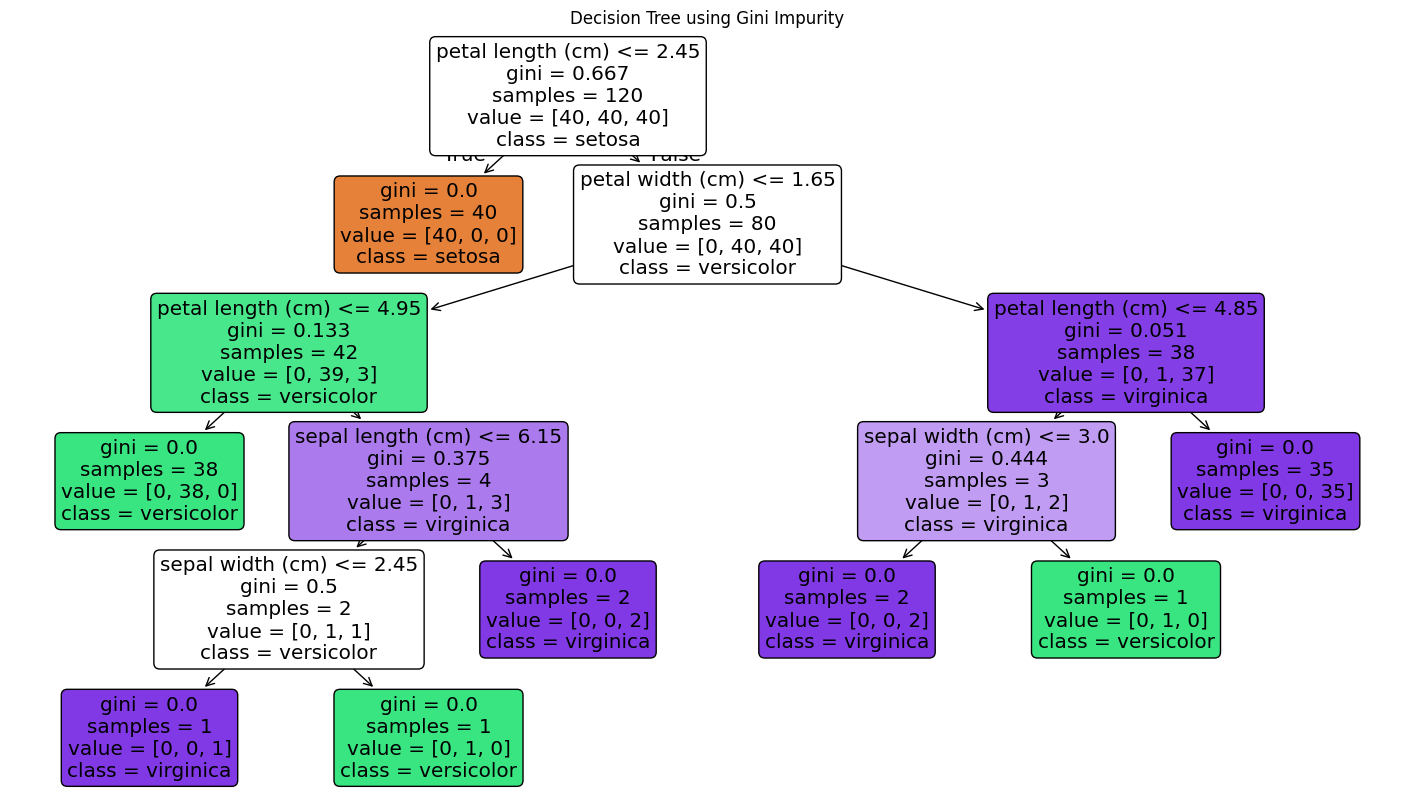

In [13]:
# Visualize the Decision Tree

plt.figure(figsize=(18, 10))

plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree using Gini Impurity")
plt.show()

In [14]:
# Compare training and testing accuracy

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

if train_accuracy > test_accuracy:
    print("\nThe model performs better on training data than testing data.")
    print("This may indicate overfitting.")
else:
    print("\nThe model is performing similarly on training and testing data.")

Training Accuracy: 1.0
Testing Accuracy: 0.9333333333333333

The model performs better on training data than testing data.
This may indicate overfitting.


In [16]:
# Create a restricted Decision Tree to reduce overfitting

tuned_dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train the tuned model
tuned_dt.fit(X_train, y_train)

print("Tuned Decision Tree trained successfully!")

Tuned Decision Tree trained successfully!


In [17]:
# Make predictions using the tuned Decision Tree

y_pred_tuned = tuned_dt.predict(X_test)

tuned_train_accuracy = tuned_dt.score(X_train, y_train)
tuned_test_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

print("Tuned Decision Tree Training Accuracy:",
      tuned_train_accuracy)

print("Tuned Decision Tree Testing Accuracy:",
      tuned_test_accuracy)

Tuned Decision Tree Training Accuracy: 0.9833333333333333
Tuned Decision Tree Testing Accuracy: 0.9666666666666667


In [18]:
# Classification report for tuned Decision Tree

print("Tuned Decision Tree Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=iris.target_names
    )
)

Tuned Decision Tree Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



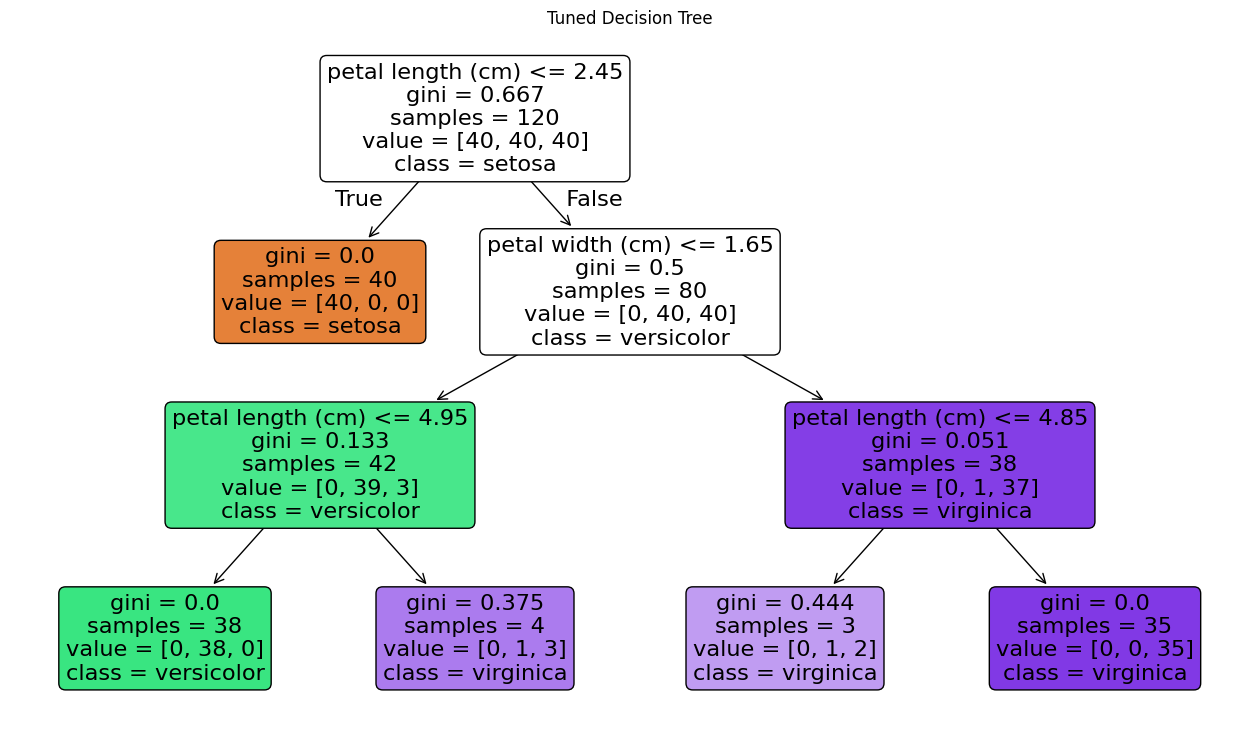

In [19]:
# Visualize the tuned Decision Tree

plt.figure(figsize=(16, 9))

plot_tree(
    tuned_dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.title("Tuned Decision Tree")
plt.show()

In [20]:
# Check whether the tree became simpler

print("Original Tree Depth:", dt_model.get_depth())
print("Original Number of Leaves:", dt_model.get_n_leaves())

print("\nTuned Tree Depth:", tuned_dt.get_depth())
print("Tuned Number of Leaves:", tuned_dt.get_n_leaves())

Original Tree Depth: 5
Original Number of Leaves: 8

Tuned Tree Depth: 3
Tuned Number of Leaves: 5


In [21]:
# Create a Random Forest classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Train the Random Forest
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [22]:
# Make predictions using Random Forest

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(y_pred_rf)

Random Forest Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 2 2 2 1 0 2 0]


In [23]:
# Calculate Random Forest accuracy

rf_train_accuracy = rf_model.score(X_train, y_train)
rf_test_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Training Accuracy:",
      rf_train_accuracy)

print("Random Forest Testing Accuracy:",
      rf_test_accuracy)

Random Forest Training Accuracy: 1.0
Random Forest Testing Accuracy: 0.9333333333333333


In [24]:
# Classification report for Random Forest

print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=iris.target_names
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [25]:
# Confusion matrix for Random Forest

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [26]:
# Calculate feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
display(feature_importance)

Random Forest Feature Importance:


,Feature,Importance
3,petal width (cm),0.438141
2,petal length (cm),0.431641
0,sepal length (cm),0.115972
1,sepal width (cm),0.014246


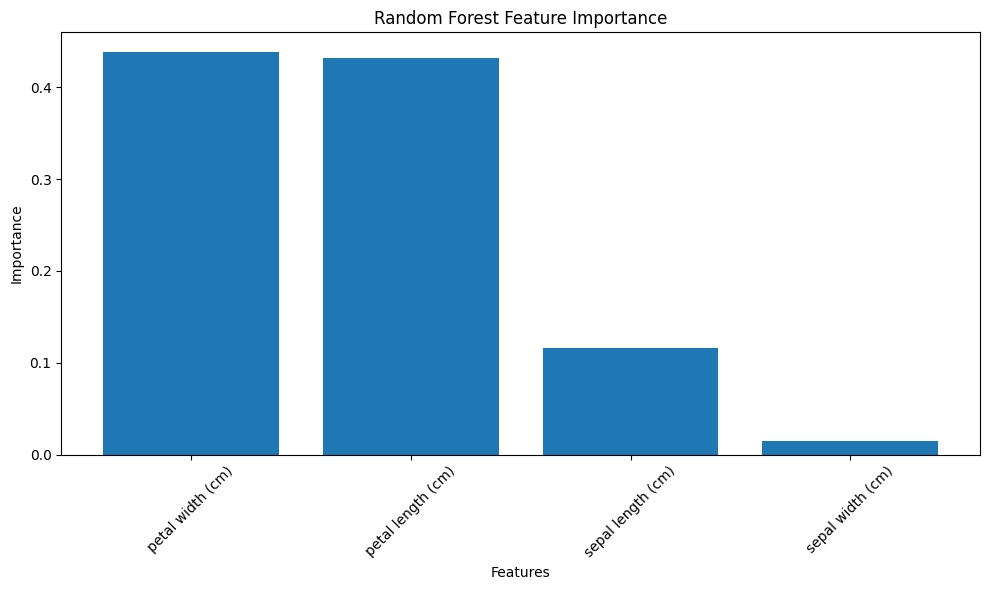

In [27]:
# Plot feature importance

plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Compare the three models

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest"
    ],
    "Training Accuracy": [
        train_accuracy,
        tuned_train_accuracy,
        rf_train_accuracy
    ],
    "Testing Accuracy": [
        test_accuracy,
        tuned_test_accuracy,
        rf_test_accuracy
    ]
})

display(comparison)

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree,1.000000,0.933333
1,Tuned Decision Tree,0.983333,0.966667
2,Random Forest,1.000000,0.933333


In [29]:
# Identify the model with the highest testing accuracy

best_model = comparison.loc[
    comparison["Testing Accuracy"].idxmax()
]

print("Best Model:")
print(best_model["Model"])

print("\nBest Testing Accuracy:")
print(best_model["Testing Accuracy"])

Best Model:
Tuned Decision Tree

Best Testing Accuracy:
0.9666666666666667
